In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DFHierarchicalCLustering.xlsx to DFHierarchicalCLustering.xlsx


In [ ]:
"""
Módulo Hierarchical Clustering
==============================

Aplicação do algoritmo de clusterização hierárquica em dados de exoplanetas,
com base nos componentes principais obtidos na etapa de pré-processamento.

Este módulo realiza a formação de clusters por meio do método hierárquico,
sua visualização no espaço PCA e a análise da similaridade dos agrupamentos
em relação às características da Terra.

As etapas são organizadas de forma modular, permitindo a extensão gradual
das análises ao longo do desenvolvimento do projeto.

Inclui:
-------
- Aplicação do algoritmo de clusterização hierárquica (linkage)
- Extração dos rótulos dos clusters
- Plot do dendrograma
- Visualização dos clusters no espaço PCA (scatter plot)
- Avaliação dos clusters em relação a planetas terrestres
- Análise de proximidade aos parâmetros terrestres
- Cálculo da distância de cada cluster ao centro terrestre
"""

import sys
sys.path.append("/content/drive/MyDrive/Notebooks-Colab/IC-Notebooks/src")

import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import importlib
from preprocessing import pca_standard_scaler

#importlib.reload(preprocessing.py)


In [ ]:
def hc_application(df_to_hc, method='ward', n_clusters=4):
    """
    3.0 Aplicação do Hierarchical Clustering
    =======================================

    Aplica o algoritmo de agrupamento hierárquico usando o método de linkage
    especificado.

    Parameters
    ----------
    df_to_hc : ndarray
        Dados de entrada (normalizados ou no espaço PCA).
    method : str, optional
        Método de linkage (default: 'ward').
    n_clusters : int, optional
        Número de clusters desejados (default: 4).

    Returns
    -------
    Z : ndarray
        Matriz de linkage.
    clusters : ndarray
        Rótulos dos clusters atribuídos a cada amostra.
    dist_corte : float
        Distância de corte correspondente à formação dos clusters.
    """
    """Z = linkage(df_to_hc[
        ['pl_orbper','pl_orbsmax','pl_rade','pl_bmasse','pl_orbeccen']
        ], method=method)
    """
    colunas_numericas = [
        'pl_orbper',
        'pl_orbsmax',
        'pl_rade',
        'pl_bmasse',
        'pl_orbeccen'
    ]
    X = df_to_hc[colunas_numericas].to_numpy()

    Z = linkage(X, method=method)

    clusters = fcluster(Z, n_clusters, criterion='maxclust')

    dist_corte = np.sort(Z[:, 2])[-(n_clusters - 1)]

    return Z, clusters, dist_corte


In [ ]:
def plot_dendrogram(Z, dist_corte=None):
    """
    3.2 Dendrograma do Agrupamento Hierárquico
    =========================================

    Plota o dendrograma correspondente à matriz de linkage obtida
    pelo algoritmo de clusterização hierárquica.

    Quando fornecida, a distância de corte é utilizada para destacar
    visualmente a separação dos clusters no dendrograma.

    Parameters
    ----------
    Z : ndarray
        Matriz de linkage gerada pelo algoritmo de clusterização.
    dist_corte : float, optional
        Distância de corte utilizada para visualização da formação
        dos clusters (default: None).
    """
    plt.figure(figsize=(18, 7))

    dendrogram(
        Z,
        color_threshold=dist_corte,
        above_threshold_color='gray',
        no_labels=True
    )

    if dist_corte is not None:
        plt.axhline(
            y=dist_corte,
            color='crimson',
            linestyle='--',
            linewidth=2,
            label=f'Corte = {dist_corte:.2f}'
        )
        plt.legend()

    plt.title(
        f'Dendrograma – Agrupamento Hierárquico)',
        fontsize=13,
        fontweight='bold'
    )

    plt.xlabel('Amostras')
    plt.ylabel('Distância Euclidiana')
    plt.ylabel('\n')
    plt.tight_layout()
    plt.show()
    print('\n')
    return


In [ ]:
def scatter_plot_PCA(X_pca, clusters, pca_model):
    # Garantir que X_pca seja array numpy (n,2)
    if isinstance(X_pca, pd.DataFrame):
        X_pca = X_pca[['PC1', 'PC2']].to_numpy()

    # Variância explicada (se disponível)
    if pca_model is not None:
        var_pc1 = pca_model.explained_variance_ratio_[0] * 100
        var_pc2 = pca_model.explained_variance_ratio_[1] * 100
        xlabel = f'PC1 ({var_pc1:.1f}% var.)'
        ylabel = f'PC2 ({var_pc2:.1f}% var.)'
    else:
        xlabel = 'PC1'
        ylabel = 'PC2'

    plt.figure(figsize=(8, 6))
    plt.title(
        'Clusters de Exoplanetas no Espaço PCA\n'
        '(Agrupamento Hierárquico - Ward)',
        fontsize=12,
        fontweight='bold'
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    for c in sorted(np.unique(clusters)):
        mask = clusters == c
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f'Cluster {c} (n={np.sum(mask)})',
            alpha=0.7,
            s=50
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print("\nESTATÍSTICAS DOS CLUSTERS:")
    for c in sorted(np.unique(clusters)):
        n = np.sum(clusters == c)
        perc = (n / len(clusters)) * 100
        print(f"Cluster {c}: {n} planetas ({perc:.1f}%)")

    return

In [ ]:
def extr_rot_clusters(df_to_hc, clusters):
  """
  3.3 - Extraindo rótulos dos clusters
  ==========================================

  Parameters
  ----------
  df_to_hc: pd.DataFrame
      Data frame com dados tratados
  clusters:
      Rótulos dos clusters

  Returns
  -------
  rotulos_clusters: pd.DataFrame
      Data frame com rótulos dos clusters
  """
  rotulos_clusters = pd.DataFrame({
      "Planeta": df_to_hc.index,
      "Cluster": clusters
  })

  return rotulos_clusters

In [ ]:
def carregar_ranges_padronizados(nome_arquivo="ranges_terrestres.json"):

    print("Selecione o arquivo JSON de ranges...")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("Nenhum arquivo foi enviado.")

    nome_arquivo = list(uploaded.keys())[0]

    with open(nome_arquivo, "r") as f:
        ranges_padronizados = json.load(f)

    print("Ranges padronizados carregados com sucesso.")

    return ranges_padronizados

In [ ]:
def analise_proximidade_terra(df_to_hc,clusters,ranges_padronizados,colunas_numericas):
    """
    3.4 - Análise de Proximidade aos Parâmetros Terrestres (L2)

    Calcula a distância Euclidiana entre o centro médio de cada cluster
    e o centro terrestre definido no espaço padronizado (z-score).

    Parameters
    ----------
    df_to_hc : pd.DataFrame
        DataFrame contendo as variáveis físicas padronizadas.
    clusters : array-like
        Rótulos dos clusters.
    ranges_padronizados : dict
        Ranges terrestres no espaço padronizado.
    colunas_numericas : list
        Lista das variáveis físicas usadas no clustering.

    Returns
    -------
    distancias : pd.Series
        Distância Euclidiana de cada cluster ao centro terrestre.
    cluster_mais_proximo : int
        Cluster mais próximo dos parâmetros terrestres.
    cluster_mais_distante : int
        Cluster mais distante dos parâmetros terrestres.
    """

    if len(df_to_hc) != len(clusters):
        raise ValueError("Número de amostras diferente do número de clusters.")

    df_clusters = df_to_hc.copy()
    df_clusters["Cluster"] = clusters

    centro_terrestre = {
        var: (lo + hi) / 2
        for var, (lo, hi) in ranges_padronizados.items()
        if var in colunas_numericas
    }

    dist_por_cluster = {}

    for c in sorted(np.unique(clusters)):

        medias_cluster = (
            df_clusters[df_clusters["Cluster"] == c][colunas_numericas]
            .mean()
        )

        soma_quadrados = 0.0

        for var in centro_terrestre.keys():
            if var in medias_cluster.index:
                diff = medias_cluster[var] - centro_terrestre[var]
                soma_quadrados += diff**2

        distancia = np.sqrt(soma_quadrados)
        dist_por_cluster[c] = distancia

    distancias = pd.Series(dist_por_cluster).sort_values()

    cluster_mais_proximo = distancias.index[0]
    cluster_mais_distante = distancias.index[-1]

    print("\nDISTÂNCIA AO CENTRO TERRESTRE(Euclidiana):")
    for cluster, dist in distancias.items():
        print(f"  Cluster {cluster}: {dist:.5f}")

    print(f"\nCluster mais próximo: {cluster_mais_proximo}")
    print(f"Cluster mais distante: {cluster_mais_distante}")

    return distancias, cluster_mais_proximo, cluster_mais_distante


In [ ]:
def exportar_para_label_propagation( df_to_hc, clusters, X_pca, caminho_saida):
    """
    Exporta dataset completo para Label Propagation:
    - features físicas padronizadas
    - rótulo do cluster hierárquico
    - coordenadas PCA
    - identificador do planeta
    """

    df_lp = df_to_hc.copy()

    # Cluster hierárquico
    df_lp["cluster_hc"] = clusters

    # Componentes principais
    df_lp["PC1"] = X_pca[:, 0]
    df_lp["PC2"] = X_pca[:, 1]

    df_lp.to_excel(caminho_saida, index=False)

    print("\nDataset para Label Propagation exportado:")
    print(f"  {caminho_saida}")

    return df_lp


In [ ]:
def cluster_info_json(cluster_mais_proximo,cluster_mais_distante, distancias, caminho_saida_json="info_proximidade.json"):
    """
    Exporta informações de proximidade dos clusters em formato JSON.

    Parameters
    ----------
    cluster_mais_proximo : int
        Cluster cujo centro está mais próximo dos parâmetros terrestres (TT).
    cluster_mais_distante : int
        Cluster cujo centro está mais distante dos parâmetros terrestres (NT).
    caminho_saida_json : str, optional
        Caminho do arquivo JSON a ser salvo.

    Returns
    -------
    dict
        Dicionário contendo as informações salvas.
    """

    info_proximidade = {
        "cluster_mais_proximo": int(cluster_mais_proximo),
        "cluster_mais_distante": int(cluster_mais_distante),
        "distancias": {
            str(k): float(v) for k, v in distancias.items()
        }
    }


    with open(caminho_saida_json, "w") as f:
        json.dump(info_proximidade, f, indent=4)

    return info_proximidade


In [ ]:
def main(caminho_entrada,n_clusters=4,metodo_linkage="ward",
         caminho_saida="DFLabelPropagation.xlsx",caminho_saida_json="info_proximidade.json"):

    # 0. Carregar dataset JÁ PADRONIZADO
    df = pd.read_excel(caminho_entrada)

    # 1. Definir colunas numéricas (já em z-score)
    colunas_numericas = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_orbeccen"]

    # 2. Hierarchical Clustering
    Z, clusters, dist_corte = hc_application(
        df[colunas_numericas],
        method=metodo_linkage,
        n_clusters=n_clusters
    )

    # 3. Dendrograma
    plot_dendrogram(Z, dist_corte)
    plt.show()

    # 4. Scatter PCA (já existe no df)
    X_pca = df.loc[:, ["PC1", "PC2"]].values
    scatter_plot_PCA(X_pca, clusters, None)
    plt.show()

    # 5. Carregar ranges padronizados
    ranges_padronizados = carregar_ranges_padronizados()

    # 6. Análise de proximidade (tudo já no mesmo espaço)
    distancias, cluster_mais_proximo, cluster_mais_distante = analise_proximidade_terra(
        df[colunas_numericas],
        clusters,
        ranges_padronizados,
        colunas_numericas
    )

    # 7. Exportações
    df_lp = df.copy()
    df_lp["cluster_hc"] = clusters

    df_lp.to_excel(caminho_saida, index=False)

    cluster_info_json(
        cluster_mais_proximo,
        cluster_mais_distante,
        distancias,
        caminho_saida_json=caminho_saida_json
    )

    print(f"\nDataset para Label Propagation salvo em: {caminho_saida}")

    return df_lp, distancias, cluster_mais_proximo, clusters, cluster_mais_distante

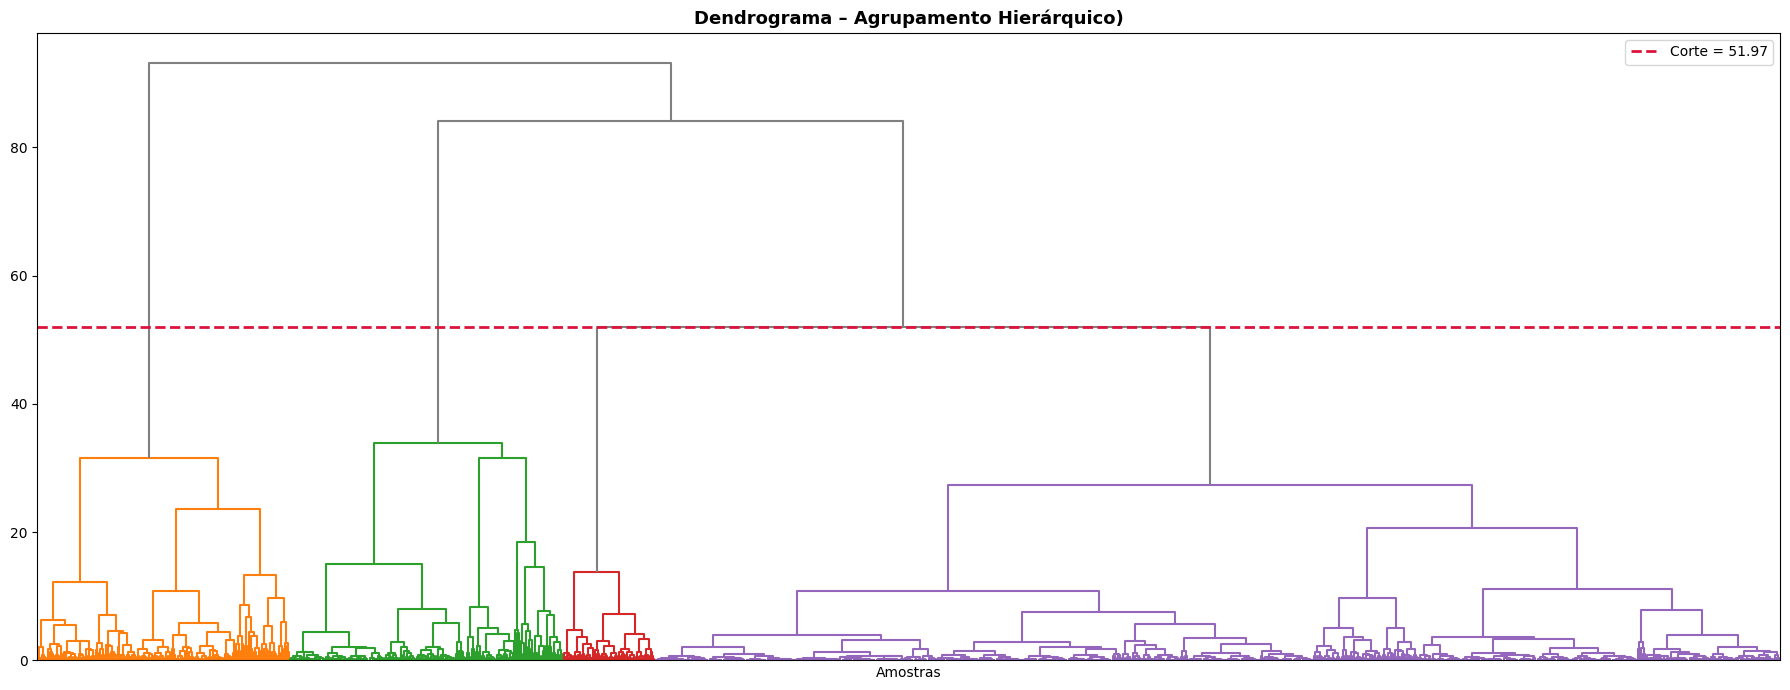

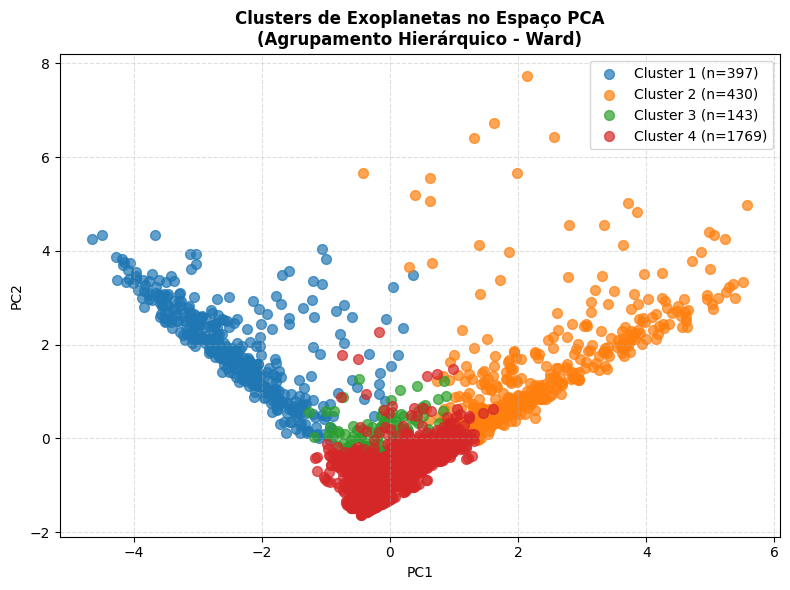


ESTATÍSTICAS DOS CLUSTERS:
Cluster 1: 397 planetas (14.5%)
Cluster 2: 430 planetas (15.7%)
Cluster 3: 143 planetas (5.2%)
Cluster 4: 1769 planetas (64.6%)
Selecione o arquivo JSON de ranges...


Saving ranges_terrestres.json to ranges_terrestres.json
Ranges padronizados carregados com sucesso.

DISTÂNCIA AO CENTRO TERRESTRE(Euclidiana):
  Cluster 2: 8.13368
  Cluster 3: 9.62542
  Cluster 4: 9.89835
  Cluster 1: 10.74904

Cluster mais próximo: 2
Cluster mais distante: 1

Dataset para Label Propagation salvo em: DFLabelPropagation.xlsx


In [ ]:
df_lp, distancias, cluster_mais_proximo, clusters, cluster_mais_distante = main(
    caminho_entrada="DFHierarchicalCLustering.xlsx",
    caminho_saida="DFLabelPropagation.xlsx",
    caminho_saida_json="info_proximidade.json"
)